# Depth study – predictive performance at L = 1, 2, 3

This notebook compares the runs in `experiments/` by number of layers. The runs fall into two families that are
**not** compared with each other:

* **WN18RRv1** – the GraIL knowledge-graph completion benchmark used in the MGNN papers. ICLR22 encoding, binary
  target (`_hypernym(x, y)` etc.), 165 positive and 165 negative test facts. Its role is to check that the pipeline
  behaves as published before it is applied to the medical data.
* **ADNI connectomes** – `data_v10` and `seed_81`. Canonical encoding, unary target `positive(patient)`, a few dozen
  test patients. This is the actual research question.

Comparing a benchmark AUPRC with a connectome AUPRC would be meaningless (different targets, encodings, class
balance and sample sizes), so every figure is produced once per family.

What is read from each experiment folder: `config.yaml`, `test_metrics.txt` (precision / recall / F1 at every
threshold of the sweep), `test_at_valid_threshold.txt` (the test row at the threshold picked on the validation split)
and `predicted_triples_scored.tsv` (score of every derived test fact). The validation split is used only to pick the
threshold and is not plotted.

Headline numbers are test precision / recall / F1 **at the validation-chosen threshold**, plus the threshold-free
AUPRC (from the metrics file) and AUROC (from the scores, via scikit-learn).

In [1]:
import sys, re, glob, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

REPO = Path.cwd().parent          # analysis_v2/ -> MGNN_v2/
sys.path.insert(0, str(REPO))
EXP = REPO / "experiments"
DATA = REPO / "data" / "link_prediction"
os.makedirs("figures", exist_ok=True)

TYPE = "http://www.w3.org/1999/02/22-rdf-syntax-ns#type"
COL = {1: "tab:blue", 2: "tab:orange", 3: "tab:green"}   # one colour per depth, used everywhere
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

# one row per experiment folder
rows = []
for f in sorted(EXP.iterdir()):
    if not (f / "config.yaml").exists():
        continue
    cfg = yaml.safe_load(open(f / "config.yaml"))
    cfg = {k.strip(): v for k, v in cfg.items()}           # 'num_layers ' has a stray space in some configs
    dataset = Path(cfg["data_dir"]).name
    ckpts = [int(re.search(r"Epoch(\d+)", p).group(1)) for p in glob.glob(str(f / "checkpoints" / "*.pt"))]
    rows.append({"run": f.name, "dataset": dataset, "L": int(cfg["num_layers"]), "encoding": cfg["encoding_scheme"],
                 "aggregations": ",".join(cfg["aggregations"]), "theta_der": float(cfg["derivation_threshold"]),
                 "last_ckpt_epoch": max(ckpts) if ckpts else None, "folder": f, "data_dir": DATA / dataset})
runs = pd.DataFrame(rows).sort_values(["dataset", "L"]).reset_index(drop=True)

# the two families of datasets are analysed separately: a KG-completion benchmark with a binary target,
# and the two ADNI connectome datasets with the unary target positive(patient)
GROUPS = {"WN18RRv1 (benchmark)": ["WN18RRv1"],
          "ADNI connectomes": [d for d in ["data_v10", "seed_81"] if d in set(runs.dataset)]}
runs.drop(columns=["folder", "data_dir"])


,run,dataset,L,encoding,aggregations,theta_der,last_ckpt_epoch
0,WN18RRv1_L1,WN18RRv1,1,iclr22,max,1.000000e-09,17000
1,WN18RRv1_L2,WN18RRv1,2,iclr22,"max,max",1.000000e-09,6000
2,WN18RRv1_L3,WN18RRv1,3,iclr22,"max,max,max",1.000000e-09,5000
3,data_v10_L1,data_v10,1,canonical,max,1.000000e-09,8000
4,data_v10_L2,data_v10,2,canonical,"max,max",1.000000e-09,0
5,data_v10_L3,data_v10,3,canonical,"max,max,max",1.000000e-09,16000
6,seed_81_L1,seed_81,1,canonical,max,1.000000e-09,7000
7,seed_81_L2,seed_81,2,canonical,"max,max",1.000000e-09,9000
8,seed_81_L3,seed_81,3,canonical,"max,max,max",1.000000e-09,0


In [2]:
def read_metrics(path):
    """test_metrics.txt / valid_metrics.txt -> (per-threshold DataFrame, AUPRC printed in the file)"""
    df = pd.read_csv(path, sep="\t", nrows=sum(1 for l in open(path) if not l.startswith("Area")) - 1)
    df.columns = ["threshold", "precision", "recall", "accuracy", "f1"]
    area = [l for l in open(path) if l.startswith("Area")]
    auprc = float(area[0].split(":")[1]) if area else None   # test_at_valid_threshold.txt has no AUPRC line
    return df, auprc

def read_tsv(path, cols):
    return pd.read_csv(path, sep="\t", header=None, names=cols, dtype=str, quoting=3, keep_default_na=False)

def example_scores(run):
    """scores the model gave to the test positives / negatives (0 if the fact was not derived at all)"""
    pred = read_tsv(run.folder / "predicted_triples_scored.tsv", ["s", "p", "o", "score"])
    pred["score"] = pred["score"].astype(float)
    lookup = dict(zip(zip(pred.s, pred.p, pred.o), pred.score))
    pos = read_tsv(run.data_dir / "test_pos.tsv", ["s", "p", "o"])
    neg = read_tsv(run.data_dir / "test_neg.tsv", ["s", "p", "o"])
    ps = np.array([lookup.get(t, 0.0) for t in zip(pos.s, pos.p, pos.o)])
    ns = np.array([lookup.get(t, 0.0) for t in zip(neg.s, neg.p, neg.o)])
    return ps, ns, pred

def slug(name):
    return re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")


## 1. Headline metrics

One row per run. `theta (valid)` is the threshold that maximised F1 on the validation split; precision, recall and F1
are the test values at that threshold. AUPRC is the area under the test precision–recall sweep as written by
`compute_metrics.py`; AP is scikit-learn's average precision from the raw scores (no threshold grid, so it is the
cleaner number when scores saturate at exactly 1.0); AUROC is rank-based. `facts derived` is the number of facts
with a score above the derivation threshold (10⁻⁹), i.e. the size of `predicted_triples.tsv`.

In [3]:
from sklearn.metrics import roc_auc_score, average_precision_score

sweeps, scores, recs = {}, {}, []
for _, r in runs.iterrows():
    sweep, auprc = read_metrics(r.folder / "test_metrics.txt")
    at_theta, _ = read_metrics(r.folder / "test_at_valid_threshold.txt")
    at_theta = at_theta.iloc[0]
    ps, ns, pred = example_scores(r)
    y = np.r_[np.ones(len(ps)), np.zeros(len(ns))]; s = np.r_[ps, ns]
    sweeps[r.run] = sweep; scores[r.run] = (ps, ns)
    recs.append({"dataset": r.dataset, "L": r.L, "epochs (>=)": r.last_ckpt_epoch, "theta (valid)": at_theta.threshold,
                 "precision": at_theta.precision, "recall": at_theta.recall, "F1": at_theta.f1,
                 "AUPRC": auprc, "AP": average_precision_score(y, s), "AUROC": roc_auc_score(y, s),
                 "n_pos": len(ps), "n_neg": len(ns), "facts derived": len(pred)})
results = pd.DataFrame(recs)
results.to_csv("results_by_depth.csv", index=False)
for name, dsets in GROUPS.items():
    print(name)
    display(results[results.dataset.isin(dsets)].round(3))


WN18RRv1 (benchmark)


,dataset,L,epochs (>=),theta (valid),precision,recall,F1,AUPRC,AP,AUROC,n_pos,n_neg,facts derived
0,WN18RRv1,1,17000,0.010,0.981,0.927,0.953,0.939,0.958,0.925,165,165,21582
1,WN18RRv1,2,6000,0.001,0.927,0.921,0.924,0.938,0.959,0.926,165,165,20565
2,WN18RRv1,3,5000,0.001,0.927,0.921,0.924,0.939,0.960,0.924,165,165,21582


ADNI connectomes


,dataset,L,epochs (>=),theta (valid),precision,recall,F1,AUPRC,AP,AUROC,n_pos,n_neg,facts derived
3,data_v10,1,8000,0.0,0.484,1.0,0.652,0.242,0.484,0.5,15,16,250325
4,data_v10,2,0,0.0,0.484,1.0,0.652,0.242,0.484,0.5,15,16,250325
5,data_v10,3,16000,0.0,0.484,1.0,0.652,0.242,0.484,0.5,15,16,250325
6,seed_81,1,7000,0.0,0.500,1.0,0.667,0.250,0.500,0.5,10,10,272493
7,seed_81,2,9000,0.0,0.500,1.0,0.667,0.250,0.500,0.5,10,10,272493
8,seed_81,3,0,0.0,0.500,1.0,0.667,0.250,0.500,0.5,10,10,272493


**Reading the tables.** On WN18RRv1 the three depths are within a few thousandths of each other on every
threshold-free metric (AUPRC ≈ 0.94, AUROC ≈ 0.92–0.93). The only visible difference, F1 0.953 at L=1 against 0.924 at
L=2/3, comes from the validation split choosing a different threshold (0.01 vs 0.001), not from the models — see
Section 3. Note also that the runs trained for very different numbers of epochs (L=1 past 17,000; L=3 stopped by
5,000), so any depth comparison is also an epoch comparison until replicates with seeds are available.

On both ADNI datasets every row is identical within a dataset: precision equals the share of positives, recall is 1,
AUROC is exactly 0.5 and the chosen threshold is 0. Those are properties of the class balance, not of the model —
Section 8 shows why.

## 2. Precision–recall curves (test split)

**Why this plot.** The PR curve shows the whole trade-off the model offers as the threshold moves, without committing
to one operating point. It is the right summary for this task because negatives vastly outnumber positives among the
candidate facts, so ROC curves would look flattering regardless. The dot on each curve is the operating point at the
validation-chosen threshold (the one reported); the dotted line is the share of positives among the test examples,
which is the precision of a model that derives everything.

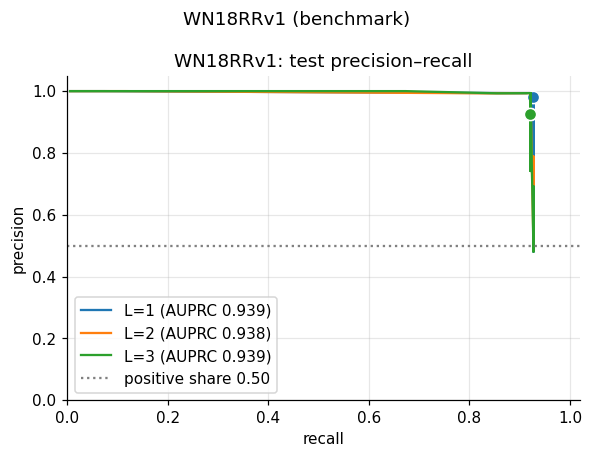

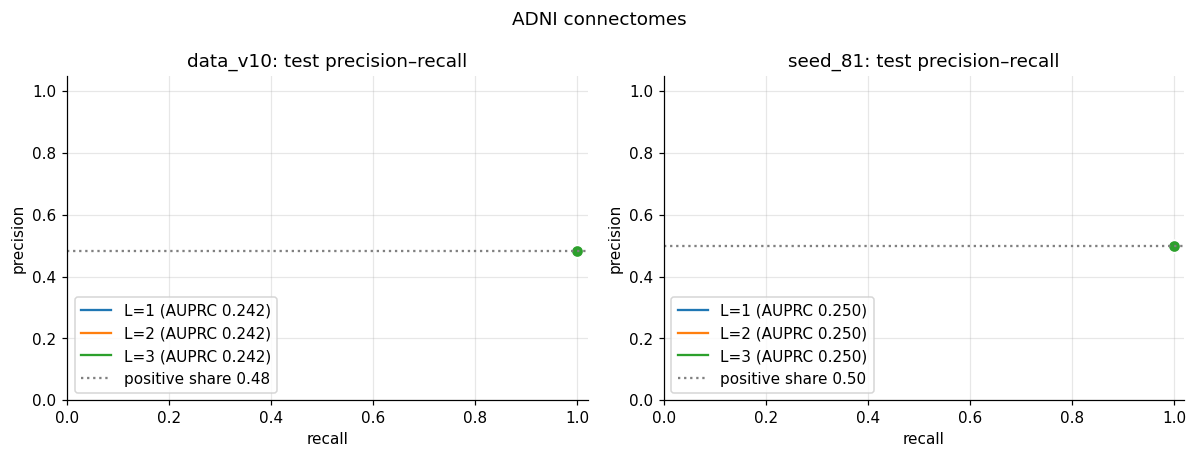

In [4]:
def pr_curves(name, dsets):
    fig, axes = plt.subplots(1, len(dsets), figsize=(5.5 * len(dsets), 4.2), squeeze=False)
    for ax, ds in zip(axes[0], dsets):
        for _, r in runs[runs.dataset == ds].iterrows():
            row = results[(results.dataset == ds) & (results.L == r.L)].iloc[0]
            sw = sweeps[r.run].dropna().sort_values("recall")
            ax.plot(sw.recall, sw.precision, color=COL[r.L], label=f"L={r.L} (AUPRC {row.AUPRC:.3f})")
            ax.plot(row.recall, row.precision, "o", color=COL[r.L], ms=8, mec="white")
        prev = row.n_pos / (row.n_pos + row.n_neg)
        ax.axhline(prev, ls=":", color="grey", label=f"positive share {prev:.2f}")
        ax.set(xlim=(0, 1.02), ylim=(0, 1.05), xlabel="recall", ylabel="precision", title=f"{ds}: test precision–recall")
        ax.legend(loc="lower left")
    fig.suptitle(name); plt.tight_layout(); plt.savefig(f"figures/pr_curves_{slug(name)}.png"); plt.show()

for name, dsets in GROUPS.items():
    pr_curves(name, dsets)


**What it shows.** *WN18RRv1:* the three curves lie on top of each other — precision stays close to 1 up to a
recall of about 0.93 and then drops vertically, because 7% of the test positives are never derived at any threshold
(Section 6 explains why). Depth does not change the curve. *ADNI:* there is no curve at all, only a single point at
(recall 1, precision = positive share) sitting on the dotted line. Every candidate patient receives the same score, so
moving the threshold either keeps all of them or drops all of them.

**Takeaway.** On the benchmark the pipeline reproduces the published behaviour and depth is irrelevant to predictive
performance. On the connectomes the models are not classifiers yet: they have learned nothing that distinguishes a
positive patient from a negative one.

## 3. F1 against the decision threshold (test split)

**Why this plot.** The headline F1 depends on the threshold chosen on validation. This plot shows how much it would
have moved for a different choice: a wide flat top means the reported number is robust, a sharp peak means it is
fragile. The x-axis is logarithmic because the sweep in `compute_metrics.py` runs from 10⁻¹⁰ to 1. The dashed vertical
line is the validation-chosen threshold for that depth.

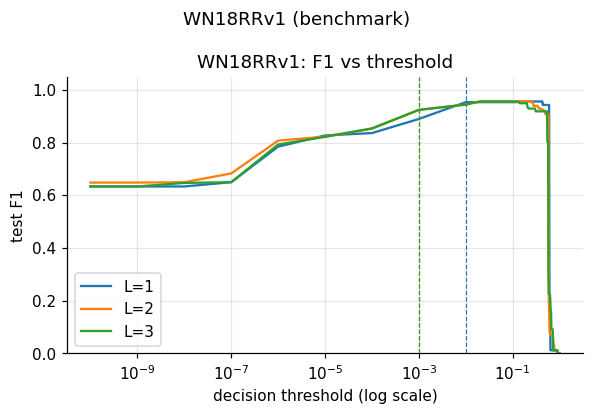

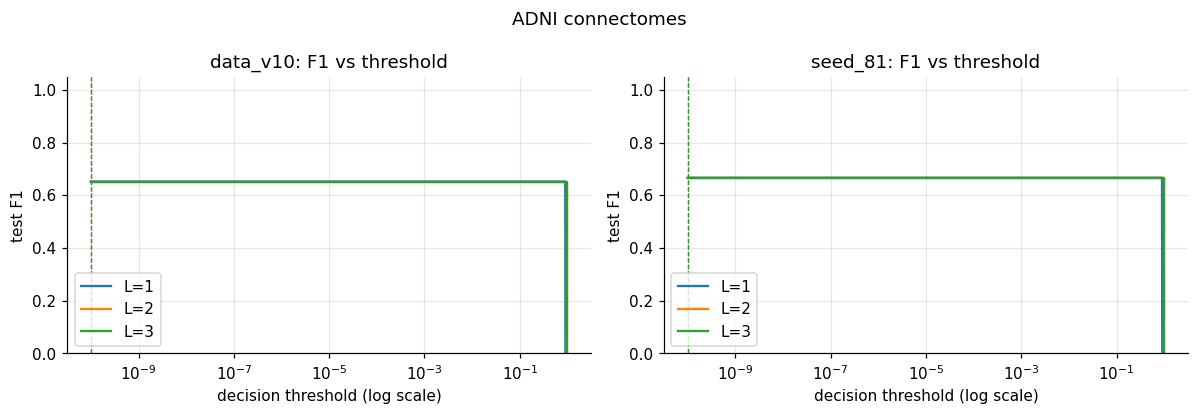

In [5]:
def f1_vs_threshold(name, dsets):
    fig, axes = plt.subplots(1, len(dsets), figsize=(5.5 * len(dsets), 3.8), squeeze=False)
    for ax, ds in zip(axes[0], dsets):
        for _, r in runs[runs.dataset == ds].iterrows():
            sw = sweeps[r.run]
            ax.plot(sw.threshold.clip(lower=1e-10), sw.f1, color=COL[r.L], label=f"L={r.L}")
            th = results[(results.dataset == ds) & (results.L == r.L)]["theta (valid)"].iloc[0]
            ax.axvline(max(th, 1e-10), color=COL[r.L], lw=0.8, ls="--")
        ax.set_xscale("log")
        ax.set(ylim=(0, 1.05), xlabel="decision threshold (log scale)", ylabel="test F1", title=f"{ds}: F1 vs threshold")
        ax.legend(loc="lower left")
    fig.suptitle(name); plt.tight_layout(); plt.savefig(f"figures/f1_vs_threshold_{slug(name)}.png"); plt.show()

for name, dsets in GROUPS.items():
    f1_vs_threshold(name, dsets)


**What it shows.** *WN18RRv1:* F1 climbs from about 0.8 at very small thresholds to a plateau above 0.9 that runs
from roughly 10⁻² to 0.5, then collapses once the threshold passes the scores of the positives (which sit near 1).
The validation split picked thresholds at the low end of that plateau (10⁻² for L=1, 10⁻³ for L=2/3), which is why
L=1 reports a slightly higher F1; at any common threshold on the plateau the three depths coincide. *ADNI:* F1 is a
horizontal line at 2·p/(1+p) (p = positive share) until the threshold reaches the single score all patients share,
then falls to zero. There is no threshold at which the model does better than "everyone is positive".

**Takeaway.** For WN18RRv1 the reported F1 is robust to the threshold; the L=1 vs L=2/3 gap in the table is a
threshold artefact, not a model difference. For ADNI the threshold is irrelevant because the scores carry no
information about the label.

## 4. Scores of the test examples

**Why this plot.** AUPRC and F1 compress the model's output to a number; this shows the output itself. Each point is
one test example, with the score the model gave it (log scale; facts that were not derived at all sit at 10⁻¹²).
A model that has learned the target puts the positives above the negatives with a gap between them. For the ADNI
datasets a third column is added: the scores the same model gives to the *region* nodes for `positive`. Regions are
never patients, so if the model separates patients from regions but not positive patients from negative ones, it has
learned "is a patient", not "has Alzheimer's".

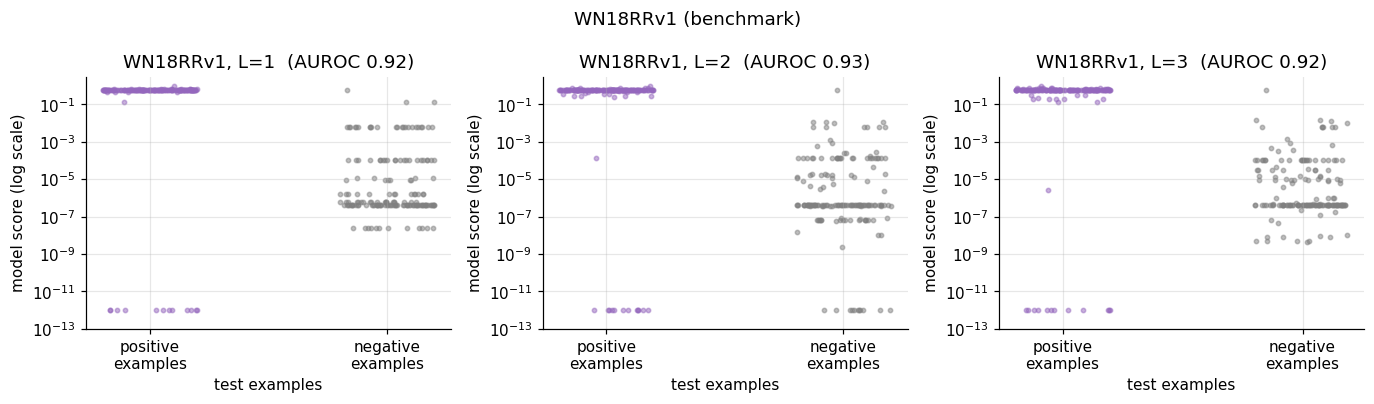

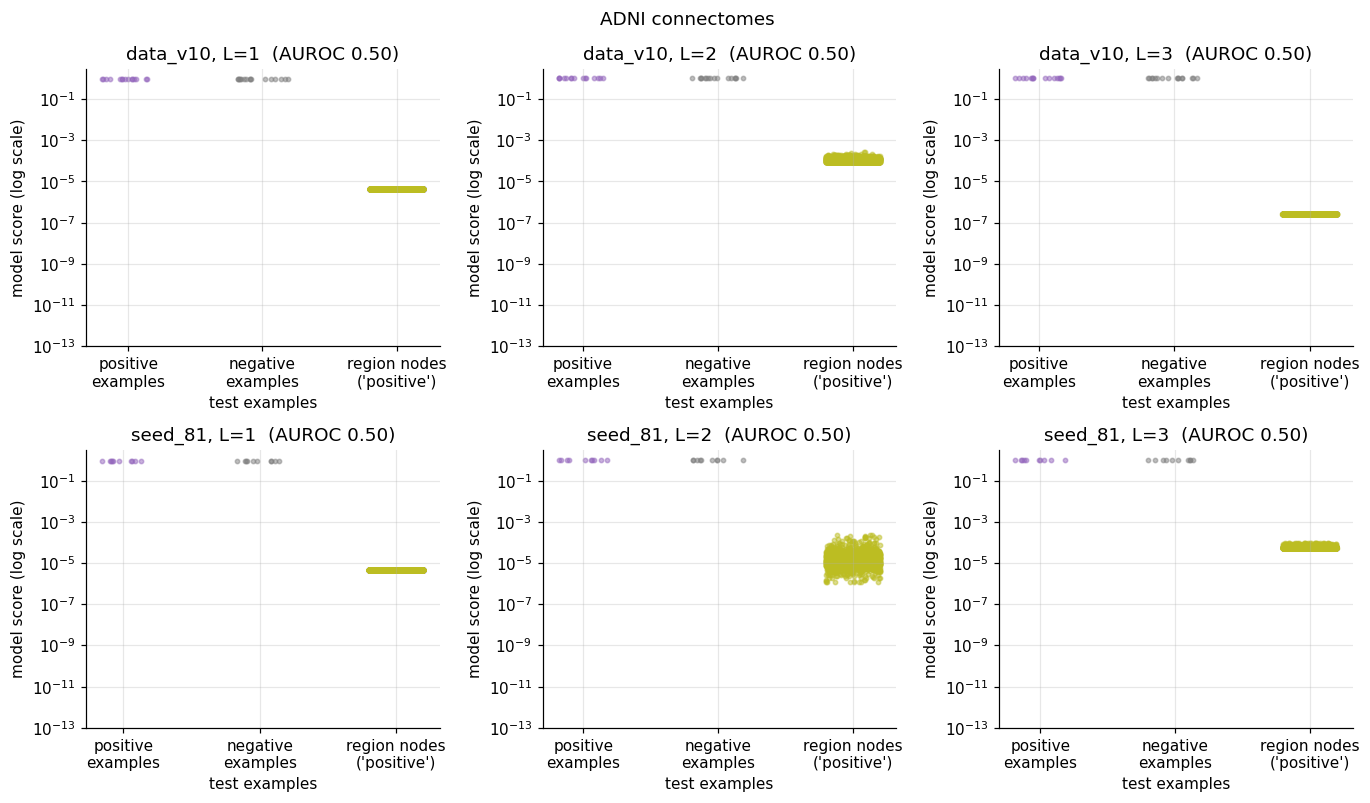

In [6]:
rng = np.random.default_rng(0)

def score_strips(name, dsets):
    Ls = sorted(runs[runs.dataset.isin(dsets)].L.unique())
    fig, axes = plt.subplots(len(dsets), len(Ls), figsize=(4.2 * len(Ls), 3.7 * len(dsets)), squeeze=False)
    for i, ds in enumerate(dsets):
        for j, L in enumerate(Ls):
            ax = axes[i, j]; sel = runs[(runs.dataset == ds) & (runs.L == L)]
            if sel.empty:
                ax.set_axis_off(); continue
            r = sel.iloc[0]; ps, ns = scores[r.run]
            groups = [("positive\nexamples", ps, "tab:purple"), ("negative\nexamples", ns, "grey")]
            if r.encoding == "canonical":            # ADNI: add the region nodes for the same predicate
                pred = example_scores(r)[2]
                examples = set(read_tsv(r.data_dir / "test_pos.tsv", ["s", "p", "o"]).s) | set(read_tsv(r.data_dir / "test_neg.tsv", ["s", "p", "o"]).s)
                others = pred[(pred.o == "positive") & (~pred.s.isin(examples))].score.to_numpy()
                groups.append(("region nodes\n('positive')", others, "tab:olive"))
            for k, (lab, arr, colr) in enumerate(groups):
                ax.scatter(k + rng.uniform(-0.2, 0.2, len(arr)), np.clip(arr, 1e-12, None), s=8, alpha=0.5, color=colr)
            auroc = results[(results.dataset == ds) & (results.L == L)].AUROC.iloc[0]
            ax.set_yscale("log")
            ax.set(xticks=range(len(groups)), xticklabels=[g[0] for g in groups], ylim=(1e-13, 3),
                   xlabel="test examples", ylabel="model score (log scale)", title=f"{ds}, L={L}  (AUROC {auroc:.2f})")
    fig.suptitle(name); plt.tight_layout(); plt.savefig(f"figures/scores_{slug(name)}.png"); plt.show()

for name, dsets in GROUPS.items():
    score_strips(name, dsets)


**What it shows.** *WN18RRv1:* positives cluster just below 1, negatives spread between 10⁻⁸ and 10⁻² with
a clear gap; the handful of positives at 10⁻¹² are the pair-less facts from Section 6. Deeper models spread the
negatives over more distinct values (a finer ranking) without changing where the positives sit. *ADNI:* positive and
negative patients are a single horizontal line at the same score (1.0 for L=2/3 on both datasets, about 0.9 for L=1),
while the region nodes sit orders of magnitude lower. The models can tell a patient from a region and nothing else.

**Takeaway.** This is the plot that explains every ADNI number in the tables. The 0.5 AUROC is not "slightly
worse than random", it is a constant classifier, and any precision or F1 quoted for these runs is just a restatement
of the class balance. Fixing this is a training-objective problem (Section 8), not a depth problem.

## 5. Depth at a glance

**Why this plot.** A compact side-by-side of the two threshold-free metrics and the reported F1 per depth, so the
depth question can be answered in one look. Bars are single runs — no error bars because there are no replicates yet.

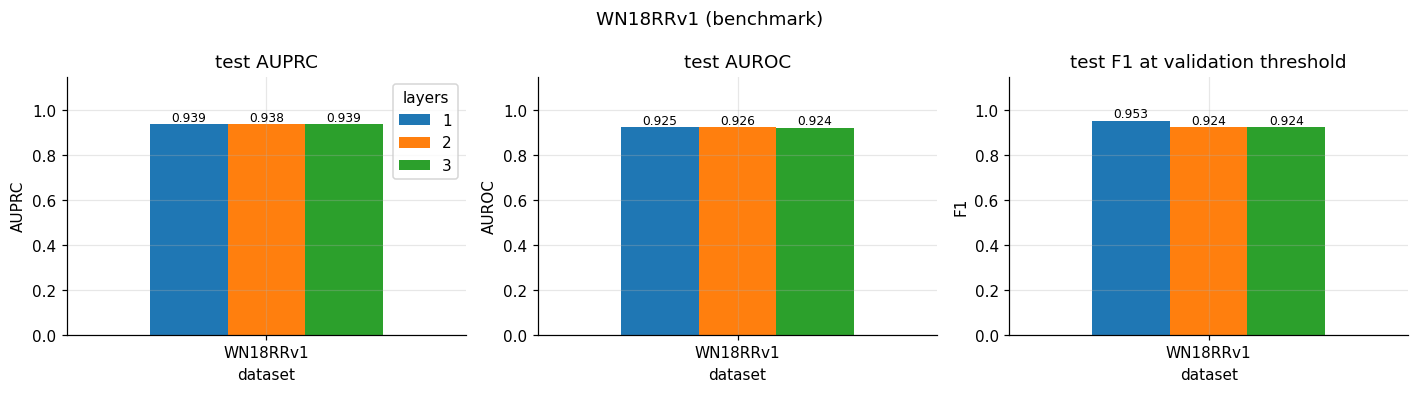

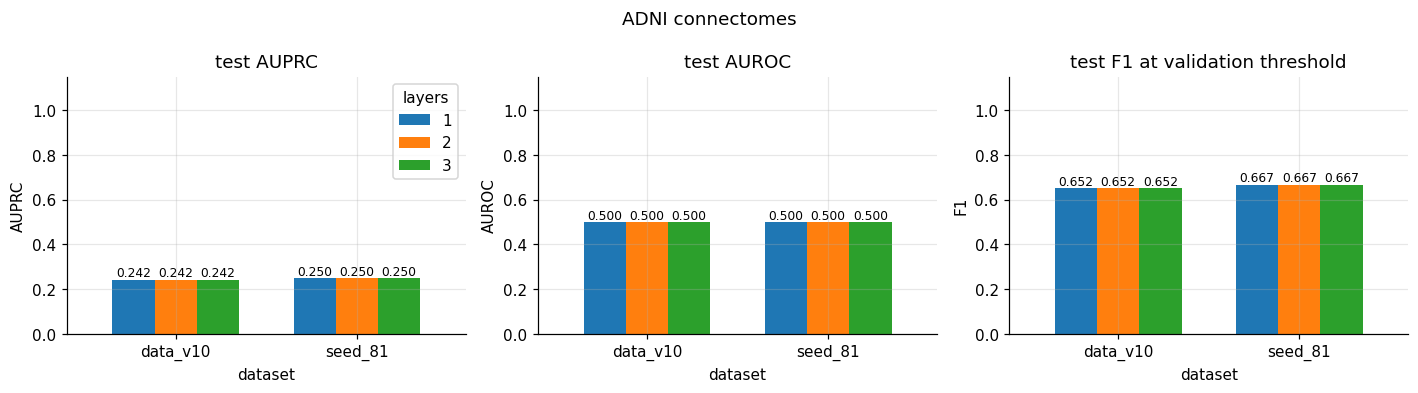

In [7]:
def depth_bars(name, dsets):
    sub = results[results.dataset.isin(dsets)]
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    for ax, m in zip(axes, ["AUPRC", "AUROC", "F1"]):
        piv = sub.pivot(index="dataset", columns="L", values=m)
        piv.plot.bar(ax=ax, color=[COL[L] for L in piv.columns], rot=0, legend=(m == "AUPRC"), width=0.7)
        for cont in ax.containers:
            ax.bar_label(cont, fmt="%.3f", fontsize=8)
        ax.set(ylim=(0, 1.15), ylabel=m, xlabel="dataset", title=f"test {m}" + (" at validation threshold" if m == "F1" else ""))
        if m == "AUPRC": ax.legend(title="layers")
    fig.suptitle(name); plt.tight_layout(); plt.savefig(f"figures/depth_bars_{slug(name)}.png"); plt.show()

for name, dsets in GROUPS.items():
    depth_bars(name, dsets)


**What it shows.** WN18RRv1: bars of equal height within each metric; the F1 difference is the threshold
artefact discussed above. ADNI: identical bars within each dataset, with AUROC pinned at 0.5.

**Takeaway.** With the current training set-up there is no measurable effect of depth on predictive performance on
either family. On the benchmark that is a real result (the encoding's recall ceiling, not model capacity, is the
limit); on the connectomes it is a non-result, because the models have not learned the target at any depth.

## 6. How much recall is even possible?

**Why this table.** Before blaming the model for missing positives it is worth checking whether it *could* have
derived them. Under the ICLR22 encoding a binary fact R(x, y) is only derivable if x and y already appear together in
some fact of the input graph — otherwise there is no pair-term node for the model to label. So the fraction of test
positives whose pair is in the test graph is a hard upper bound on recall. With the canonical encoding and a unary
target the corresponding condition is just that the subject is a node of the graph. The validation split is included
in the table because it is where the threshold is chosen.

In [8]:
ceil = []
for ds in runs.dataset.unique():
    r = runs[runs.dataset == ds].iloc[0]
    for split in ["valid", "test"]:
        g = read_tsv(r.data_dir / f"{split}_graph.tsv", ["s", "p", "o"])
        pos = read_tsv(r.data_dir / f"{split}_pos.tsv", ["s", "p", "o"])
        binary = g[g.p != TYPE]
        if r.encoding == "iclr22":
            pairs = set(zip(binary.s, binary.o)) | set(zip(binary.o, binary.s))
            cov = np.mean([(s, o) in pairs for s, o in zip(pos.s, pos.o)])
        else:
            nodes = set(g.s) | set(binary.o)
            cov = np.mean([s in nodes for s in pos.s])
        ceil.append({"dataset": ds, "split": split, "graph facts": len(g), "positives": len(pos), "recall ceiling": round(cov, 3)})
ceil = pd.DataFrame(ceil)
best = results.groupby("dataset").recall.max().round(3)
print("highest test recall actually reached (any depth):", best.to_dict())
ceil


highest test recall actually reached (any depth): {'WN18RRv1': 0.927, 'data_v10': 1.0, 'seed_81': 1.0}


,dataset,split,graph facts,positives,recall ceiling
0,WN18RRv1,valid,499,131,0.053
1,WN18RRv1,test,1641,165,0.927
2,data_v10,valid,140470,28,1.000
3,data_v10,test,79174,15,1.000
4,seed_81,valid,237832,9,1.000
5,seed_81,test,239112,10,1.000


**What it shows.** On WN18RRv1 the test ceiling is 0.927 and the best recall any depth reaches is exactly 0.927:
the models derive every positive the encoding lets them derive. On the *validation* split the ceiling is 0.053 — the
validation graph is tiny (499 facts) and almost none of the validation positives have their pair in it. That is the
"validation–test discrepancy": validation AUPRC is low not because the model generalises badly but because the
validation graph gives it nothing to work with, and it also means validation F1 is a weak basis for choosing the
threshold on this dataset. On the ADNI data the ceiling is 1 on both splits, so no structural excuse exists there.

**Takeaway.** For WN18RRv1 recall is decided by the encoding, not the depth. Any future improvement on that dataset
has to come from the encoding (e.g. dummy constants) rather than from the network.

## 7. Extracted rules

**Why this table.** Depth is supposed to show up in the rules more than in the metrics: an L-layer model can only
express rule bodies that are trees of depth ≤ L, and the basic explanation Γ grows with L. `run_experiment.py`
explains the first derived fact in dictionary order (`list(predictions)[:1]`), so there is one rule per run. The
columns count body atoms, distinct variables and `top-pred` placeholder atoms (the ICLR22 unfolding's stand-in for
"these two constants co-occur"). An empty body means the head was derived from the bias alone.

WN18RRv1 (benchmark)


,dataset,L,explained fact,body atoms,variables,placeholders,empty body,rule
0,WN18RRv1,1,"('01693881', '_hypernym', '09964805')",1,2,1,False,"<_hypernym>[?X0,?X1] :- <top-pred>[?X0,?X1] ."
1,WN18RRv1,2,"('01693881', '_hypernym', '09964805')",1,2,1,False,"<_hypernym>[?X0,?X1] :- <top-pred>[?X0,?X1] ."
2,WN18RRv1,3,"('01693881', '_hypernym', '09964805')",22,22,12,False,"<_hypernym>[?X0,?X1] :- <top-pred>[?X0,?X2], <..."


ADNI connectomes


,dataset,L,explained fact,body atoms,variables,placeholders,empty body,rule
3,data_v10,1,"('041_S_0679_0', 'http://www.w3.org/1999/02/22...",0,0,0,True,<positive>[?X0] :- .
4,data_v10,2,"('041_S_0679_0', 'http://www.w3.org/1999/02/22...",42,20,0,False,<positive>[?X0] :- <ctx-lh-inferiorparietal>[?...
5,data_v10,3,"('041_S_0679_0', 'http://www.w3.org/1999/02/22...",0,0,0,True,<positive>[?X0] :- .
6,seed_81,1,"('sub-ADNI003S4354_ses-M066_0', 'http://www.w3...",0,0,0,True,<node_0>[?X0] :- .
7,seed_81,2,"('sub-ADNI003S4354_ses-M066_0', 'http://www.w3...",0,0,0,True,<node_0>[?X0] :- .
8,seed_81,3,"('sub-ADNI003S4354_ses-M066_0', 'http://www.w3...",0,0,0,True,<node_0>[?X0] :- .


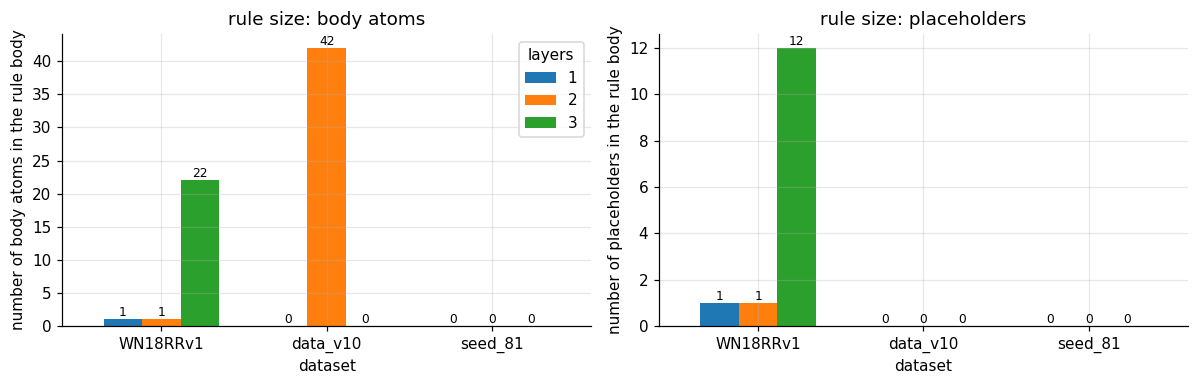

In [9]:
rule_rows = []
for _, r in runs.iterrows():
    lines = open(r.folder / "explanations.txt").read().splitlines()
    for fact, rule in zip(lines[::2], lines[1::2]):
        body = rule.split(":-")[1].strip().rstrip(".").strip()
        atoms = re.findall(r"<([^>]+)>\[([^\]]*)\]", body)
        variables = {v for _, vs in atoms for v in vs.split(",")}
        rule_rows.append({"dataset": r.dataset, "L": r.L, "explained fact": fact, "body atoms": len(atoms),
                          "variables": len(variables), "placeholders": sum(p == "top-pred" for p, _ in atoms),
                          "empty body": len(atoms) == 0, "rule": rule[:110] + ("..." if len(rule) > 110 else "")})
rules = pd.DataFrame(rule_rows)
for name, dsets in GROUPS.items():
    print(name); display(rules[rules.dataset.isin(dsets)])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, colname in zip(axes, ["body atoms", "placeholders"]):
    piv = rules.pivot(index="dataset", columns="L", values=colname)
    piv.plot.bar(ax=ax, color=[COL[L] for L in piv.columns], rot=0, width=0.7, legend=(colname == "body atoms"))
    for cont in ax.containers:
        ax.bar_label(cont, fontsize=8)
    ax.set(xlabel="dataset", ylabel=f"number of {colname} in the rule body", title=f"rule size: {colname}")
    if colname == "body atoms": ax.legend(title="layers")
plt.tight_layout(); plt.savefig("figures/rule_size.png"); plt.show()


**What it shows.** *WN18RRv1:* L=1 and L=2 both explain `_hypernym(01693881, 09964805)` with the single atom
`top-pred(X0, X1)` — i.e. "the two constants co-occur", which is all the encoding guarantees and says nothing about
*why* the model chose hypernym. L=3 produces a 22-atom body with 12 placeholders: the extra layer reaches further into
the graph and Γ grows accordingly, but the rule is not minimised so most of it is noise. *ADNI:* the explained fact is a
`region` node, not a patient (it is simply the first fact in the dictionary), and in five of the six ADNI runs the body is empty —
the fact was derived from the bias alone at a threshold of 10⁻⁹ (on seed_81 the explained fact is even `node_0(region)`,
a label the region already carries in the input). The one exception, L=2 on data_v10, returns a 42-atom body listing
specific regions and strength-1.0 connections, which is a description of that one region's neighbourhood rather than a
rule about Alzheimer's.

**Takeaway.** Depth does change the rules, roughly as the theory says, but none of the current rules is a usable
finding. Three things are needed before rule extraction is informative here: explain facts about *patients*, raise the
derivation threshold above the bias floor so that "derived" means something (see the audit), and run the
minimisation step so Γ is reduced to what is actually necessary.

## 8. Notes for the write-up

Automatic checks on the numbers above. Anything printed here should be dealt with, or at least stated, before the
results are reported.

In [10]:
for _, r in results.iterrows():
    if abs(r.AUROC - 0.5) < 0.02:
        print(f"{r.dataset} L={r.L}: AUROC {r.AUROC:.2f} -> positives and negatives get the same scores; this is a constant classifier")
    if r["theta (valid)"] == 0:
        print(f"{r.dataset} L={r.L}: validation picked threshold 0 -> no threshold separates the classes on validation")
    if r["epochs (>=)"] is not None and r["epochs (>=)"] < 1000:
        print(f"{r.dataset} L={r.L}: stopped before the first 1000-epoch checkpoint")
for _, r in rules.iterrows():
    if r["empty body"]:
        print(f"{r.dataset} L={r.L}: extracted rule has an empty body (fact derived from the bias alone)")


data_v10 L=1: AUROC 0.50 -> positives and negatives get the same scores; this is a constant classifier
data_v10 L=1: validation picked threshold 0 -> no threshold separates the classes on validation
data_v10 L=2: AUROC 0.50 -> positives and negatives get the same scores; this is a constant classifier
data_v10 L=2: validation picked threshold 0 -> no threshold separates the classes on validation
data_v10 L=2: stopped before the first 1000-epoch checkpoint
data_v10 L=3: AUROC 0.50 -> positives and negatives get the same scores; this is a constant classifier
data_v10 L=3: validation picked threshold 0 -> no threshold separates the classes on validation
seed_81 L=1: AUROC 0.50 -> positives and negatives get the same scores; this is a constant classifier
seed_81 L=1: validation picked threshold 0 -> no threshold separates the classes on validation
seed_81 L=2: AUROC 0.50 -> positives and negatives get the same scores; this is a constant classifier
seed_81 L=2: validation picked threshold 0 

**Where the ADNI failure comes from (for the discussion chapter).** `train.py` builds the target matrix as zeros
everywhere except the positive training examples and applies the weighted BCE loss to *every* node and *every*
predicate position — on seed_81 that is on the order of 10⁸ zero targets against 75 ones, and most of those zeros are
meaningless (the model is told not to output `node_17` at a region labelled `node_17`). The negative training patients
in `train_neg.tsv` are never read and get the same weight as any other cell. The cheapest fix is to compute the loss
only at the `positive` position of patient nodes, with the negative patients weighted comparably to the positives.
Until that is done, depth cannot be studied on the connectome data because there is no signal for depth to act on.